In [142]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data as a bunch
iris_data = load_iris()

target_names = iris_data.target_names # obtain the iris species names
feature_names = iris_data.feature_names

# load the data dirctly as dfs
df_X, df_y = load_iris(return_X_y=True,as_frame=True)

df_y_labels = df_y.to_frame (name="species_int_label")

df_y_names = pd.DataFrame(target_names[df_y_labels],columns=["species_name"])


In [143]:

def compute_KMeans(data):

    model = KMeans ( n_clusters = 3 ) # instantiate the KMeans model as model

    model. fit ( data ) # using the model instantiation, fit it to the data in “df”

    labels = model. predict ( data ) # use the predict method of the model on the same samples to generate a label for each cluster to which it assessed to belong.

    print(model.inertia_)

    return labels,model

In [144]:
def plot_results(data, labels, name_dim1, name_dim2):

    xs = data [ name_dim1 ]
    ys = data [ name_dim2 ]

    for label in np.unique(labels):
        mask = labels == label
        plt.scatter(xs[mask], ys[mask], alpha=0.5, label=f"Cluster {label}")

    plt.xlabel(name_dim1)
    plt.ylabel(name_dim2)
    plt.legend()

    # Assign the cluster centers: centroids
    centroids = model.cluster_centers_

    # Assign the columns of centroids: centroids_x, centroids_y
    df_centroids = pd.DataFrame(centroids,columns=data.columns)

    # Add Make a scatter plot of centroids_x and centroids_y
    plt.scatter(df_centroids[name_dim1],df_centroids[name_dim2],marker="D",s=50)

    plt.show()


In [145]:
# turn the predicted labels into a df

def crosstab_results(df_X, df_y, df_y_names, labels, data_name=None):

    df_labels = pd.DataFrame(labels,columns=["KMeans_label"])
    df_com = pd.concat([df_X,df_y,df_y_names,df_labels], axis =1)

    df_crosstab = pd.crosstab(df_com["KMeans_label"],df_com[data_name])

    return df_crosstab

In [146]:
def crosstab_results(df_X,dy_y,df_y_names,labels,actual_data_names=None):
    df_labels = pd.DataFrame(labels,columns=["KMeans_label"])
    df_com = pd.concat([df_X,df_y,df_y_names,df_labels], axis =1)
    df_crosstab = pd.crosstab(df_com["KMeans_label"],df_com[actual_data_names])

    print(df_crosstab)


78.851441426146


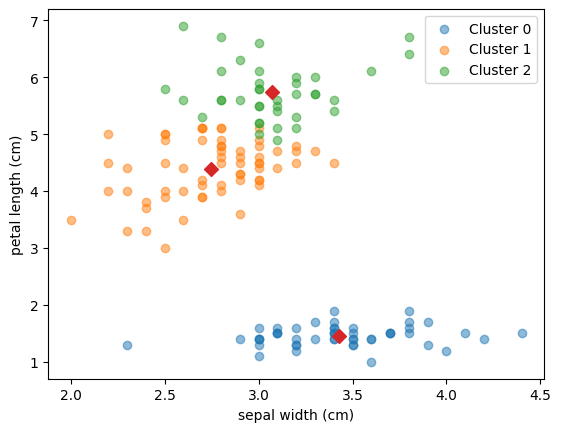

species_name  setosa  versicolor  virginica
KMeans_label                               
0                 50           0          0
1                  0          48         14
2                  0           2         36


In [147]:
# run the model
labels,model = compute_KMeans(df_X)

# scatterplot of observations plus cluster centroids
# specify two column names within df_X to plot these as required
plot_results ( df_X, labels, "sepal width (cm)", "petal length (cm)" )

# crosstab the results
crosstab_results(df_X, df_y , df_y_names, labels,"species_name")

In [148]:
scaler = StandardScaler()
scaler.fit(df_X)

array_X_scaled = scaler.transform(df_X)
df_X_scaled = pd.DataFrame(array_X_scaled,columns=df_X.columns)

print (df_X_scaled)

print (df_X_scaled.describe().apply(lambda x: x.apply('{0:.2f}'.format)))

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0            -0.900681          1.019004          -1.340227         -1.315444
1            -1.143017         -0.131979          -1.340227         -1.315444
2            -1.385353          0.328414          -1.397064         -1.315444
3            -1.506521          0.098217          -1.283389         -1.315444
4            -1.021849          1.249201          -1.340227         -1.315444
..                 ...               ...                ...               ...
145           1.038005         -0.131979           0.819596          1.448832
146           0.553333         -1.282963           0.705921          0.922303
147           0.795669         -0.131979           0.819596          1.053935
148           0.432165          0.788808           0.933271          1.448832
149           0.068662         -0.131979           0.762758          0.790671

[150 rows x 4 columns]
      sepal length (cm) sepal width (cm)

140.90153181202442
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0            -0.900681          1.019004          -1.340227         -1.315444
1            -1.143017         -0.131979          -1.340227         -1.315444
2            -1.385353          0.328414          -1.397064         -1.315444
3            -1.506521          0.098217          -1.283389         -1.315444
4            -1.021849          1.249201          -1.340227         -1.315444
..                 ...               ...                ...               ...
145           1.038005         -0.131979           0.819596          1.448832
146           0.553333         -1.282963           0.705921          0.922303
147           0.795669         -0.131979           0.819596          1.053935
148           0.432165          0.788808           0.933271          1.448832
149           0.068662         -0.131979           0.762758          0.790671

[150 rows x 4 columns]


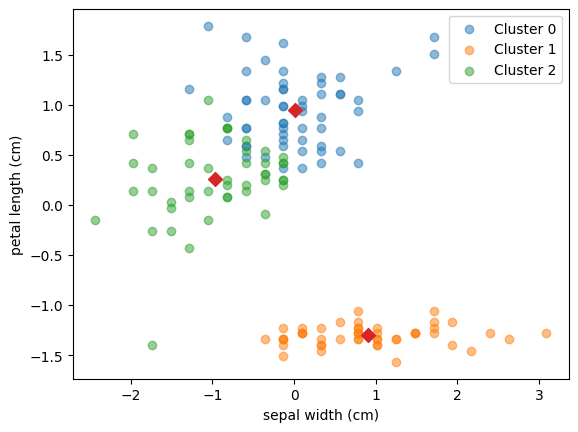

species_name  setosa  versicolor  virginica
KMeans_label                               
0                  0          13         42
1                 49           0          0
2                  1          37          8


In [149]:
# run the model
labels, model = compute_KMeans(df_X_scaled)
print(df_X_scaled)
# scatterplot of observations plus cluster centroids
# specify two column names within df_X to plot these as required
plot_results ( df_X_scaled, labels, "sepal width (cm)", "petal length (cm)" )

# crosstab the results
crosstab_results(df_X_scaled, df_y , df_y_names, labels,"species_name")